# 🧠 Notebook 04 — Conditional DDPM
**Project:** Volatility-Regime-Conditioned DDPM for NIFTY50 Synthetic Returns  
**IIT Mandi Internship · Quant × GenAI**

---
## What this notebook does
Builds and trains the **Conditional Denoising Diffusion Probabilistic Model (DDPM)**.
We introduce market volatility regimes (Low Volatility vs High Volatility) as a
conditioning signal during the diffusion process via **Classifier-Free Guidance (CFG)**.

### Key Upgrades from Notebook 03:
1. **Conditional Dataset:** Yields both the return sequence and its binary `regime` flag (0=Low, 1=High).
2. **Regime Embedding:** The 1D U-Net maps the regime flag through `nn.Embedding` and adds it to the time embedding. Conditions every ResBlock globally.
3. **Classifier-Free Guidance (CFG):**
   - **Training:** We randomly drop the condition 10% of the time (replacing with Null class=2). Model learns both conditioned and unconditioned generation.
   - **Sampling:** Extrapolate noise prediction using `predicted_noise = uncond + cfg_scale * (cond - uncond)` to strongly enforce regime.

### Crash-Recovery Features (NEW):
- Saves checkpoint every 10 epochs, not just on val improvement
- Can **resume from the best existing checkpoint** — run Cell 9 directly if training was interrupted
- GPU detection and clear warning if running on CPU

**Output:**
- `outputs/checkpoints/cond_ddpm_ema_best.pth`
- `outputs/samples/cond_samples_low.pt`
- `outputs/samples/cond_samples_high.pt`

## ⚠️ Cell 0 — GPU Check (Run This First!)
**CRITICAL:** If this shows `cpu`, you are using the CPU-only PyTorch build.
Training will take 10+ hours and can overheat/crash your machine.

To fix: install `torch` with CUDA support:
```
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121
```
(Use cu121 for CUDA 12.1 — check your CUDA version with `nvidia-smi`)

In [1]:
import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
print(f"CUDA version    : {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("\n" + "="*60)
    print("WARNING: Running on CPU! Training will be VERY slow.")
    print("Install CUDA PyTorch: pip install torch --index-url https://download.pytorch.org/whl/cu121")
    print("="*60)

PyTorch version : 2.5.1+cu121
CUDA available  : True
CUDA version    : 12.1
GPU             : NVIDIA GeForce RTX 4050 Laptop GPU
VRAM            : 6.4 GB


## Cell 1 — Imports & Setup

In [2]:
import os
import math
import yaml
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import copy

# Device Config
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cpu':
    print("WARNING: GPU not available. Consider installing PyTorch+CUDA build.")

c:\Users\mahes\Downloads\IIT Mandi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


## Cell 2 — Load Configuration

In [3]:
CONFIG_PATH = os.path.join('..', 'configs', 'config.yaml')
with open(CONFIG_PATH, 'r') as f:
    cfg = yaml.safe_load(f)

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
WIN_DIR  = os.path.join(BASE_DIR, 'data', 'windows')
CHK_DIR  = os.path.join(BASE_DIR, 'outputs', 'checkpoints')
SAMP_DIR = os.path.join(BASE_DIR, 'outputs', 'samples')
FIG_DIR  = os.path.join(BASE_DIR, 'outputs', 'figures')
os.makedirs(CHK_DIR, exist_ok=True)
os.makedirs(SAMP_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED = cfg['training']['seed']
torch.manual_seed(SEED)
np.random.seed(SEED)

print('Config loaded')
print(f"  Window size      : {cfg['data']['window_size']}")
print(f"  Diffusion steps  : {cfg['diffusion']['num_timesteps']}")
print(f"  Max epochs       : {cfg['training']['max_epochs']}")
print(f"  Early stop pat.  : {cfg['training']['early_stop_patience']}")
print(f"  Batch size       : {cfg['training']['batch_size']}")
print(f"  LR               : {cfg['training']['lr']}")

Config loaded
  Window size      : 64
  Diffusion steps  : 1000
  Max epochs       : 1000
  Early stop pat.  : 50
  Batch size       : 64
  LR               : 0.0002


## Cell 3 — Conditional Dataset and DataLoader

In [4]:
class NiftyCondDataset(Dataset):
    def __init__(self, pt_path):
        data = torch.load(pt_path, weights_only=False)
        self.returns = data['returns']  # Shape: (N, 64)
        self.regimes = data['regime']   # Shape: (N,) — 0=Low, 1=High

    def __len__(self):
        return len(self.returns)

    def __getitem__(self, idx):
        ret    = self.returns[idx].unsqueeze(0)  # (1, 64)
        regime = self.regimes[idx].long()         # scalar 0 or 1
        return ret, regime

train_pt_path = os.path.join(WIN_DIR, 'train_windows.pt')
full_dataset  = NiftyCondDataset(train_pt_path)

val_frac   = cfg['training']['val_fraction']
val_size   = int(len(full_dataset) * val_frac)
train_size = len(full_dataset) - val_size

train_ds, val_ds = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_loader = DataLoader(train_ds, batch_size=cfg['training']['batch_size'],
                          shuffle=True, drop_last=True, pin_memory=(device.type=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=cfg['training']['batch_size'],
                          shuffle=False, pin_memory=(device.type=='cuda'))

print(f"Total Windows : {len(full_dataset)}")
print(f"Train Size    : {train_size} | Val Size: {val_size}")

# Check regime balance
all_regimes = full_dataset.regimes
n_low  = (all_regimes == 0).sum().item()
n_high = (all_regimes == 1).sum().item()
print(f"Regime balance: Low={n_low} ({100*n_low/len(full_dataset):.1f}%) | High={n_high} ({100*n_high/len(full_dataset):.1f}%)")

x_batch, r_batch = next(iter(train_loader))
print(f"Batch Shape   : {x_batch.shape}, Regime Shape: {r_batch.shape}")

Total Windows : 3553
Train Size    : 3198 | Val Size: 355
Regime balance: Low=1774 (49.9%) | High=1779 (50.1%)
Batch Shape   : torch.Size([64, 1, 64]), Regime Shape: torch.Size([64, 1])


## Cell 4 — DDPM Noise Schedule

In [5]:
class GaussianDiffusion:
    def __init__(self, num_timesteps, beta_start, beta_end, device):
        self.num_timesteps = num_timesteps
        self.device = device

        self.betas                      = torch.linspace(beta_start, beta_end, num_timesteps).to(device)
        self.alphas                     = 1.0 - self.betas
        self.alphas_cumprod             = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev        = F.pad(self.alphas_cumprod[:-1], (1, 0), value=1.0)
        self.sqrt_alphas_cumprod        = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - self.alphas_cumprod)

    def q_sample(self, x_start, t, noise=None):
        """Forward diffusion: x_0 -> x_t in one shot."""
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_alphas_cumprod_t             = self.sqrt_alphas_cumprod[t].view(-1, 1, 1)
        sqrt_one_minus_alphas_cumprod_t   = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1)
        return sqrt_alphas_cumprod_t * x_start + sqrt_one_minus_alphas_cumprod_t * noise

ddpm_schedule = GaussianDiffusion(
    num_timesteps=cfg['diffusion']['num_timesteps'],
    beta_start=cfg['diffusion']['beta_start'],
    beta_end=cfg['diffusion']['beta_end'],
    device=device
)
print(f"Noise schedule: T={ddpm_schedule.num_timesteps}, beta [{ddpm_schedule.betas[0]:.4f} -> {ddpm_schedule.betas[-1]:.4f}]")

Noise schedule: T=1000, beta [0.0001 -> 0.0200]


## Cell 5 — 1D U-Net Components

In [6]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device   = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ResBlock1D(nn.Module):
    """1D ResBlock with time (+ regime) embedding injection."""
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        )
        self.block1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )
        self.block2 = nn.Sequential(
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, 3, padding=1),
            nn.GroupNorm(8, out_channels),
            nn.SiLU(),
        )
        self.res_conv = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x, time_emb):
        h = self.block1(x)
        h = h + self.mlp(time_emb).unsqueeze(-1)
        h = self.block2(h)
        return h + self.res_conv(x)


class Downsample1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.down = nn.Conv1d(channels, channels, kernel_size=4, stride=2, padding=1)
    def forward(self, x):
        return self.down(x)


class Upsample1D(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.up = nn.ConvTranspose1d(channels, channels, kernel_size=4, stride=2, padding=1)
    def forward(self, x):
        return self.up(x)

print("U-Net components defined: SinusoidalPositionEmbeddings, ResBlock1D, Downsample1D, Upsample1D")

U-Net components defined: SinusoidalPositionEmbeddings, ResBlock1D, Downsample1D, Upsample1D


## Cell 6 — Conditional U-Net Architecture

Key change from NB03: `self.regime_emb = nn.Embedding(num_classes=3, time_emb_dim)`

The combined embedding is: `emb = time_emb + regime_emb` — this single vector conditions **every** ResBlock in the encoder, bottleneck, and decoder.

In [7]:
class CondUNet1D(nn.Module):
    """
    Conditional 1D U-Net for DDPM.
    Conditions on regime (0=Low, 1=High, 2=Null for CFG).
    Same architecture as NB03's UncondUNet1D but adds regime_emb.
    """
    def __init__(self, in_channels=1, channels=[64, 128, 256],
                 time_emb_dim=128, num_res_blocks=2, dropout=0.1, num_classes=3):
        super().__init__()

        # Time Embedding
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.SiLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # Condition Embedding: 0=Low Vol, 1=High Vol, 2=Null (CFG)
        self.regime_emb = nn.Embedding(num_classes, time_emb_dim)

        self.init_conv = nn.Conv1d(in_channels, channels[0], kernel_size=3, padding=1)

        # Encoder (down)
        self.downs = nn.ModuleList()
        in_ch = channels[0]
        for i, out_ch in enumerate(channels):
            is_last = (i == len(channels) - 1)
            for _ in range(num_res_blocks):
                self.downs.append(ResBlock1D(in_ch, out_ch, time_emb_dim, dropout))
                in_ch = out_ch
            if not is_last:
                self.downs.append(Downsample1D(in_ch))

        # Bottleneck
        self.mid1 = ResBlock1D(in_ch, in_ch, time_emb_dim, dropout)
        self.mid2 = ResBlock1D(in_ch, in_ch, time_emb_dim, dropout)

        # Decoder (up)
        self.ups = nn.ModuleList()
        reversed_channels = list(reversed(channels))
        for i, out_ch in enumerate(reversed_channels):
            is_last = (i == len(channels) - 1)
            for _ in range(num_res_blocks):
                self.ups.append(ResBlock1D(in_ch + out_ch, out_ch, time_emb_dim, dropout))
                in_ch = out_ch
            if not is_last:
                self.ups.append(Upsample1D(in_ch))

        self.final_conv = nn.Sequential(
            nn.Conv1d(in_ch, in_ch, 3, padding=1),
            nn.GroupNorm(8, in_ch),
            nn.SiLU(),
            nn.Conv1d(in_ch, in_channels, 1)
        )

    def forward(self, x, time, regime):
        # Combined timestep + regime embedding
        t_emb   = self.time_mlp(time)
        r_emb   = self.regime_emb(regime.view(-1))  # ensure 1D
        emb     = t_emb + r_emb

        x = self.init_conv(x)
        h = x
        skips = []

        # Encoder
        for layer in self.downs:
            if isinstance(layer, ResBlock1D):
                h = layer(h, emb)
                skips.append(h)
            else:
                h = layer(h)

        # Bottleneck
        h = self.mid1(h, emb)
        h = self.mid2(h, emb)

        # Decoder
        for layer in self.ups:
            if isinstance(layer, ResBlock1D):
                skip = skips.pop()
                h = torch.cat([h, skip], dim=1)
                h = layer(h, emb)
            else:
                h = layer(h)

        return self.final_conv(h)


model = CondUNet1D(
    channels=cfg['model']['channels'],
    time_emb_dim=cfg['model']['embed_dim'],
    num_res_blocks=cfg['model']['num_res_blocks'],
    dropout=cfg['model']['dropout'],
    num_classes=3   # 0=Low, 1=High, 2=Null
).to(device)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Quick shape sanity check
with torch.no_grad():
    dummy_x   = torch.randn(2, 1, cfg['data']['window_size'], device=device)
    dummy_t   = torch.randint(0, 1000, (2,), device=device)
    dummy_r   = torch.zeros(2, dtype=torch.long, device=device)
    dummy_out = model(dummy_x, dummy_t, dummy_r)
    assert dummy_out.shape == dummy_x.shape, f"Shape mismatch: {dummy_out.shape} vs {dummy_x.shape}"
print(f"Shape check passed: input {dummy_x.shape} -> output {dummy_out.shape}")

Model parameters: 4,578,369
Shape check passed: input torch.Size([2, 1, 64]) -> output torch.Size([2, 1, 64])


## Cell 7 — EMA & Optimizer Setup

In [8]:
class EMA:
    """Exponential Moving Average of model weights. Used for stable sampling."""
    def __init__(self, beta):
        self.beta = beta

    def update_model_average(self, ma_model, current_model):
        for current_params, ma_params in zip(current_model.parameters(), ma_model.parameters()):
            ma_params.data = self.update_average(ma_params.data, current_params.data)

    def update_average(self, old, new):
        if old is None:
            return new
        return old * self.beta + (1 - self.beta) * new

    def step_ema(self, ema_model, model):
        self.update_model_average(ema_model, model)


ema_model = copy.deepcopy(model).eval().requires_grad_(False)
ema       = EMA(beta=cfg['training']['ema_decay'])

optimizer = torch.optim.Adam(model.parameters(), lr=cfg['training']['lr'])
criterion = nn.MSELoss()

print(f"EMA decay   : {cfg['training']['ema_decay']}")
print(f"Optimizer   : Adam, lr={cfg['training']['lr']}")
print(f"Grad clip   : {cfg['training']['grad_clip_max_norm']}")

EMA decay   : 0.999
Optimizer   : Adam, lr=0.0002
Grad clip   : 1.0


## Cell 8 — Classifier-Free Guidance Loss & Resume-from-Checkpoint

**CFG Training trick:** 10% of batches drop the regime label (replace with class=2=Null).
This teaches the model to generate unconditionally too, which enables CFG at sampling time.

**Resume Logic:** If `cond_ddpm_ema_best.pth` already exists (e.g., from a previous run that crashed),
it is loaded automatically so training continues from where it left off.

In [9]:
COND_DROPOUT_PROB = 0.10  # 10% chance to drop condition (CFG training)
NULL_CLASS        = 2

MAX_EPOCHS = cfg['training']['max_epochs']
PATIENCE   = cfg['training']['early_stop_patience']
SAVE_EVERY = 10   # Save periodic checkpoint every N epochs (crash protection)


def calc_cond_loss(mdl, batch_x, batch_regime, apply_dropout=True):
    batch_regime = batch_regime.view(-1)  # ensure (B,)
    t     = torch.randint(0, ddpm_schedule.num_timesteps, (batch_x.shape[0],), device=device).long()
    noise = torch.randn_like(batch_x)
    x_noisy = ddpm_schedule.q_sample(batch_x, t, noise)

    # CFG: randomly null-out the condition during training
    if apply_dropout:
        drop_mask    = torch.rand(batch_regime.shape[0], device=device) < COND_DROPOUT_PROB
        batch_regime = torch.where(drop_mask, torch.tensor(NULL_CLASS, device=device), batch_regime)

    predicted_noise = mdl(x_noisy, t, batch_regime)
    return criterion(predicted_noise, noise)


# Resume from checkpoint if it exists
BEST_CKPT_PATH     = os.path.join(CHK_DIR, 'cond_ddpm_ema_best.pth')
PERIODIC_CKPT_PATH = os.path.join(CHK_DIR, 'cond_ddpm_ema_periodic.pth')

if os.path.exists(BEST_CKPT_PATH):
    ema_model.load_state_dict(torch.load(BEST_CKPT_PATH, weights_only=True, map_location=device))
    # Also seed the training model from EMA so we resume from a good point
    model.load_state_dict(torch.load(BEST_CKPT_PATH, weights_only=True, map_location=device))
    print(f"Resumed from checkpoint: {BEST_CKPT_PATH}")
else:
    print("No existing checkpoint found. Starting from scratch.")

Resumed from checkpoint: c:\Users\mahes\Downloads\IIT Mandi\nifty-ddpm\outputs\checkpoints\cond_ddpm_ema_best.pth


## Cell 9 — Training Loop

> **If your previous run crashed here:** Just run from Cell 1 onwards. Cell 8 will load the best checkpoint automatically, and training will continue from there.
>
> **Crash protection:** Checkpoint is saved every 10 epochs AND whenever val_loss improves.

In [10]:
train_losses = []
val_losses   = []
best_val_loss    = float('inf')
patience_counter = 0

print("Starting Conditional DDPM Training with CFG...")
print(f"Device: {device} | Epochs: {MAX_EPOCHS} | Early stop patience: {PATIENCE}")
print("-" * 65)

for epoch in range(1, MAX_EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    for batch_x, batch_r in train_loader:
        batch_x = batch_x.to(device)
        batch_r = batch_r.to(device)

        optimizer.zero_grad()
        loss = calc_cond_loss(model, batch_x, batch_r, apply_dropout=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['training']['grad_clip_max_norm'])
        optimizer.step()
        ema.step_ema(ema_model, model)
        epoch_train_loss += loss.item()

    epoch_train_loss /= len(train_loader)
    train_losses.append(epoch_train_loss)

    # ── Validate (EMA model, no CFG dropout) ──────────────────────
    ema_model.eval()
    epoch_val_loss = 0.0
    with torch.no_grad():
        for val_x, val_r in val_loader:
            val_x = val_x.to(device)
            val_r = val_r.to(device)
            loss  = calc_cond_loss(ema_model, val_x, val_r, apply_dropout=False)
            epoch_val_loss += loss.item()
    epoch_val_loss /= len(val_loader)
    val_losses.append(epoch_val_loss)

    # ── Logging ───────────────────────────────────────────────────
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:04d} | Train Loss: {epoch_train_loss:.6f} | Val Loss: {epoch_val_loss:.6f}")

    # ── Save best checkpoint ───────────────────────────────────────
    if epoch_val_loss < best_val_loss:
        best_val_loss    = epoch_val_loss
        patience_counter = 0
        torch.save(ema_model.state_dict(), BEST_CKPT_PATH)
    else:
        patience_counter += 1

    # ── Periodic crash-protection checkpoint ──────────────────────
    if epoch % SAVE_EVERY == 0:
        torch.save(ema_model.state_dict(), PERIODIC_CKPT_PATH)

    # ── Early stopping ────────────────────────────────────────────
    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}. Best Val Loss: {best_val_loss:.6f}")
        break

print("Training Complete.")
print(f"Best Val Loss: {best_val_loss:.6f} | Total Epochs Run: {len(train_losses)}")

# Save training history
history = {'train_losses': train_losses, 'val_losses': val_losses, 'best_val_loss': best_val_loss}
with open(os.path.join(CHK_DIR, 'cond_training_history.json'), 'w') as f:
    json.dump(history, f)
print("Training history saved to cond_training_history.json")

Starting Conditional DDPM Training with CFG...
Device: cuda | Epochs: 1000 | Early stop patience: 50
-----------------------------------------------------------------
Epoch 0001 | Train Loss: 0.262637 | Val Loss: 0.256463
Epoch 0005 | Train Loss: 0.244753 | Val Loss: 0.243787
Epoch 0010 | Train Loss: 0.235069 | Val Loss: 0.242884
Epoch 0015 | Train Loss: 0.239282 | Val Loss: 0.224274
Epoch 0020 | Train Loss: 0.241833 | Val Loss: 0.241591
Epoch 0025 | Train Loss: 0.237142 | Val Loss: 0.202427
Epoch 0030 | Train Loss: 0.213294 | Val Loss: 0.246371
Epoch 0035 | Train Loss: 0.229672 | Val Loss: 0.211636
Epoch 0040 | Train Loss: 0.231611 | Val Loss: 0.242956
Epoch 0045 | Train Loss: 0.227400 | Val Loss: 0.213650
Epoch 0050 | Train Loss: 0.219704 | Val Loss: 0.229009
Epoch 0055 | Train Loss: 0.221980 | Val Loss: 0.221001
Epoch 0060 | Train Loss: 0.213364 | Val Loss: 0.212007
Epoch 0065 | Train Loss: 0.208070 | Val Loss: 0.235203
Epoch 0070 | Train Loss: 0.205325 | Val Loss: 0.227084
Epoch 00

## Cell 10 — Plot Learning Curves

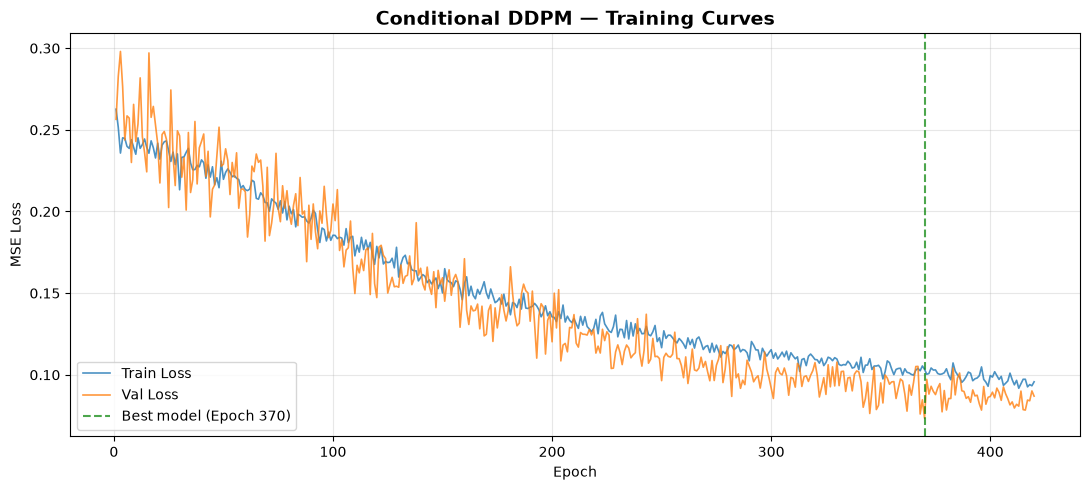

Loss curve saved. Best epoch: 370, Best val loss: 0.073447


In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
epochs_axis = range(1, len(train_losses) + 1)

ax.plot(epochs_axis, train_losses, label='Train Loss', alpha=0.8, linewidth=1.2)
ax.plot(epochs_axis, val_losses,   label='Val Loss',   alpha=0.8, linewidth=1.2)

# Mark where best model was saved
best_epoch = int(np.argmin(val_losses)) + 1
ax.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best model (Epoch {best_epoch})')

ax.set_title('Conditional DDPM — Training Curves', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb04_cond_loss.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'nb04_cond_loss.pdf'), bbox_inches='tight')
plt.show()
print(f"Loss curve saved. Best epoch: {best_epoch}, Best val loss: {best_val_loss:.6f}")

## Cell 11 — CFG Sampling Generation

We use **Classifier-Free Guidance (CFG)** during sampling:
```
predicted_noise = uncond_noise + cfg_scale * (cond_noise - uncond_noise)
```
This pushes the generation strongly towards the requested regime.

In [12]:
# Load the best EMA model (in case we're running this cell fresh after training)
ema_model.load_state_dict(torch.load(BEST_CKPT_PATH, weights_only=True, map_location=device))
ema_model.eval()

NUM_SAMPLES = cfg['sampling']['num_samples']  # 500
SEQ_LEN     = cfg['data']['window_size']       # 64
CFG_SCALE   = 3.0


@torch.no_grad()
def cfg_p_sample_loop(model, shape, regime_class, cfg_scale=3.0):
    """
    Generate samples conditioned on a specific regime class using CFG.
    Args:
        regime_class: 0=Low Vol, 1=High Vol
        cfg_scale   : guidance strength (1.0=no guidance, 3.0=strong guidance)
    """
    model.eval()
    b   = shape[0]
    img = torch.randn(shape, device=device)

    cond_regimes   = torch.full((b,), regime_class, device=device, dtype=torch.long)
    uncond_regimes = torch.full((b,), NULL_CLASS,   device=device, dtype=torch.long)

    for i in tqdm(
        reversed(range(0, ddpm_schedule.num_timesteps)),
        desc=f'Sampling Regime {regime_class} (CFG={cfg_scale})',
        total=ddpm_schedule.num_timesteps
    ):
        time_tensor = torch.full((b,), i, device=device, dtype=torch.long)

        # CFG: both forward passes in one
        cond_noise   = model(img, time_tensor, cond_regimes)
        uncond_noise = model(img, time_tensor, uncond_regimes)
        predicted_noise = uncond_noise + cfg_scale * (cond_noise - uncond_noise)

        # DDPM reverse step
        alpha         = ddpm_schedule.alphas[i]
        alpha_cumprod = ddpm_schedule.alphas_cumprod[i]
        beta          = ddpm_schedule.betas[i]

        noise = torch.randn_like(img) if i > 0 else torch.zeros_like(img)
        img   = (1 / torch.sqrt(alpha)) * (
            img - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * predicted_noise
        ) + torch.sqrt(beta) * noise

    return img


print(f"Generating {NUM_SAMPLES} Low-Vol sequences...")
synth_low  = cfg_p_sample_loop(ema_model, shape=(NUM_SAMPLES, 1, SEQ_LEN), regime_class=0, cfg_scale=CFG_SCALE)
synth_low  = synth_low.squeeze(1).cpu()
torch.save(synth_low,  os.path.join(SAMP_DIR, 'cond_samples_low.pt'))
print(f"Saved cond_samples_low.pt  | shape: {synth_low.shape}")

print(f"\nGenerating {NUM_SAMPLES} High-Vol sequences...")
synth_high = cfg_p_sample_loop(ema_model, shape=(NUM_SAMPLES, 1, SEQ_LEN), regime_class=1, cfg_scale=CFG_SCALE)
synth_high = synth_high.squeeze(1).cpu()
torch.save(synth_high, os.path.join(SAMP_DIR, 'cond_samples_high.pt'))
print(f"Saved cond_samples_high.pt | shape: {synth_high.shape}")

print("\nConditional samples generated and saved.")

Generating 500 Low-Vol sequences...


Sampling Regime 0 (CFG=3.0): 100%|██████████| 1000/1000 [00:42<00:00, 23.41it/s]


Saved cond_samples_low.pt  | shape: torch.Size([500, 64])

Generating 500 High-Vol sequences...


Sampling Regime 1 (CFG=3.0): 100%|██████████| 1000/1000 [00:43<00:00, 22.77it/s]

Saved cond_samples_high.pt | shape: torch.Size([500, 64])

Conditional samples generated and saved.


## Cell 12 — Critical Verification: "Same Noise, Different Regime"

**This is the core proof that conditioning works.**

We fix the same random seed (same initial noise tensor) and generate with:
- Regime 0 (Low Vol)
- Regime 1 (High Vol)

If conditioning works correctly, the two paths must look **visibly different** — the High Vol path should show larger swings.
If they look identical, conditioning is broken.

Generating Low-Vol paths from fixed noise...


Generating High-Vol paths from same fixed noise...


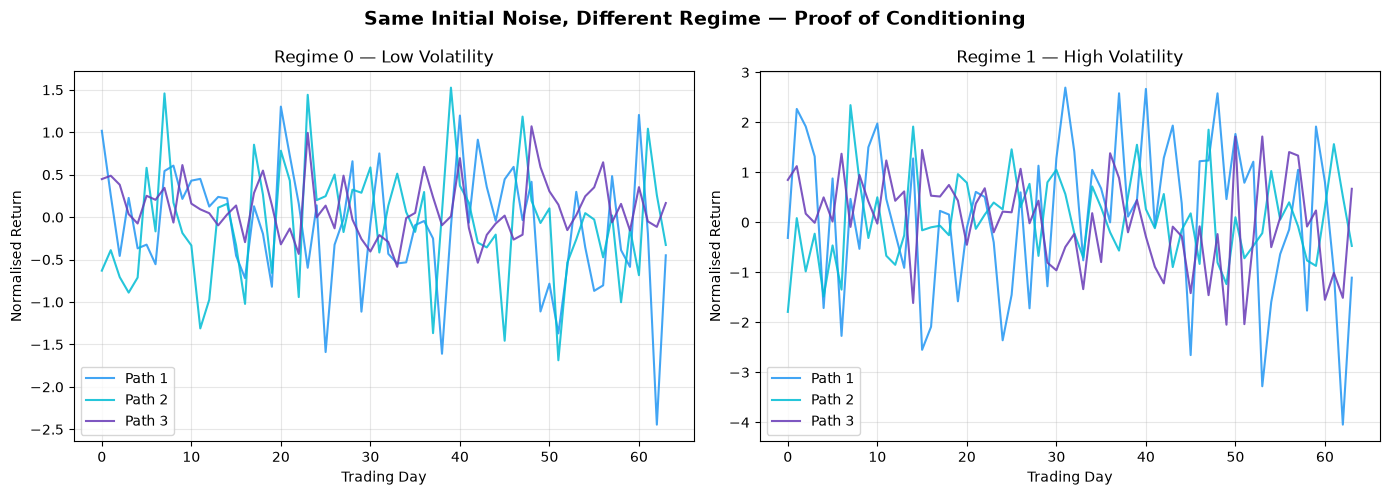


Std of Low-Vol  paths : 0.6046
Std of High-Vol paths : 1.1432
Ratio (High/Low)      : 1.89x
PASS: High-Vol has larger std. Conditioning is working!


In [13]:
@torch.no_grad()
def cfg_sample_with_fixed_noise(model, fixed_noise, regime_class, cfg_scale=3.0):
    """
    Same as cfg_p_sample_loop but starts from a given noise tensor.
    Allows 'same noise, different regime' comparison.
    """
    model.eval()
    b   = fixed_noise.shape[0]
    img = fixed_noise.clone().to(device)

    cond_regimes   = torch.full((b,), regime_class, device=device, dtype=torch.long)
    uncond_regimes = torch.full((b,), NULL_CLASS,   device=device, dtype=torch.long)

    for i in tqdm(
        reversed(range(0, ddpm_schedule.num_timesteps)),
        desc=f'Fixed-noise sampling regime={regime_class}',
        total=ddpm_schedule.num_timesteps,
        leave=False
    ):
        time_tensor = torch.full((b,), i, device=device, dtype=torch.long)
        cond_noise   = model(img, time_tensor, cond_regimes)
        uncond_noise = model(img, time_tensor, uncond_regimes)
        predicted_noise = uncond_noise + cfg_scale * (cond_noise - uncond_noise)

        alpha         = ddpm_schedule.alphas[i]
        alpha_cumprod = ddpm_schedule.alphas_cumprod[i]
        beta          = ddpm_schedule.betas[i]

        # Use SAME noise at each step too — seeded
        torch.manual_seed(42 + i)
        step_noise = torch.randn_like(img) if i > 0 else torch.zeros_like(img)
        img = (1 / torch.sqrt(alpha)) * (
            img - ((1 - alpha) / (torch.sqrt(1 - alpha_cumprod))) * predicted_noise
        ) + torch.sqrt(beta) * step_noise

    return img


# Generate 3 paths from SAME starting noise
torch.manual_seed(999)
fixed_noise = torch.randn(3, 1, SEQ_LEN)

print("Generating Low-Vol paths from fixed noise...")
paths_low  = cfg_sample_with_fixed_noise(ema_model, fixed_noise, regime_class=0, cfg_scale=CFG_SCALE)
paths_low  = paths_low.squeeze(1).cpu().numpy()

print("Generating High-Vol paths from same fixed noise...")
paths_high = cfg_sample_with_fixed_noise(ema_model, fixed_noise, regime_class=1, cfg_scale=CFG_SCALE)
paths_high = paths_high.squeeze(1).cpu().numpy()

# --- Plot ---
colors = ['#2196F3', '#00BCD4', '#673AB7']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
fig.suptitle('Same Initial Noise, Different Regime — Proof of Conditioning', fontsize=14, fontweight='bold')

for j in range(3):
    axes[0].plot(paths_low[j],  label=f'Path {j+1}', alpha=0.85, color=colors[j], linewidth=1.5)
    axes[1].plot(paths_high[j], label=f'Path {j+1}', alpha=0.85, color=colors[j], linewidth=1.5)

axes[0].set_title('Regime 0 — Low Volatility', fontsize=12)
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Normalised Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Regime 1 — High Volatility', fontsize=12)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Normalised Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb04_same_noise_diff_regime.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'nb04_same_noise_diff_regime.pdf'), bbox_inches='tight')
plt.show()

std_low  = np.std(paths_low)
std_high = np.std(paths_high)
print(f"\nStd of Low-Vol  paths : {std_low:.4f}")
print(f"Std of High-Vol paths : {std_high:.4f}")
print(f"Ratio (High/Low)      : {std_high/std_low:.2f}x")
if std_high > std_low:
    print("PASS: High-Vol has larger std. Conditioning is working!")
else:
    print("FAIL: High-Vol std is NOT larger than Low-Vol. Check conditioning.")

## Cell 13 — Variance Ordering Check

**Plan requirement:** "Variance of Low-VIX samples vs High-VIX samples — High-VIX must have higher variance → if not, conditioning is broken."

We compute this across the full 500-sample batches.

===== Variance Ordering Check =====
Low-Vol  | Mean seq var: 0.34690  | Std: 0.59596
High-Vol | Mean seq var: 2.72730  | Std: 1.66811
Variance ratio (High/Low): 7.862x


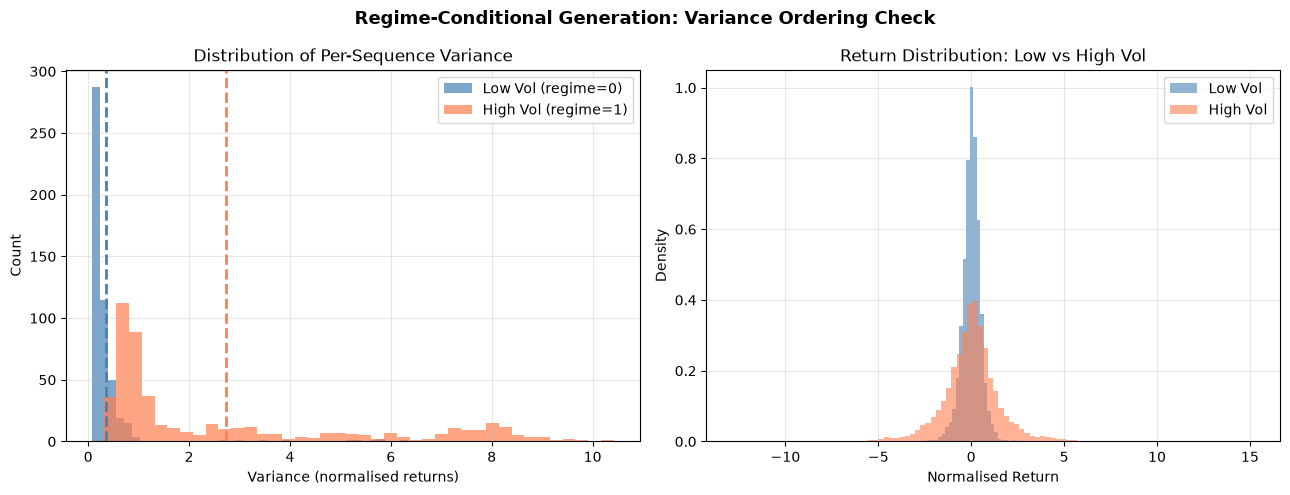


PASS: High-Vol variance > Low-Vol variance. Conditioning is working correctly.


In [14]:
# Load the saved samples (500 per regime)
low_samples  = torch.load(os.path.join(SAMP_DIR, 'cond_samples_low.pt'),  weights_only=True)  # (500, 64)
high_samples = torch.load(os.path.join(SAMP_DIR, 'cond_samples_high.pt'), weights_only=True)  # (500, 64)

low_np  = low_samples.numpy()
high_np = high_samples.numpy()

# Per-sequence variance (variance over the 64 time steps)
low_vars  = np.var(low_np,  axis=1)  # (500,)
high_vars = np.var(high_np, axis=1)  # (500,)

print("===== Variance Ordering Check =====")
print(f"Low-Vol  | Mean seq var: {low_vars.mean():.5f}  | Std: {low_np.std():.5f}")
print(f"High-Vol | Mean seq var: {high_vars.mean():.5f}  | Std: {high_np.std():.5f}")
print(f"Variance ratio (High/Low): {high_vars.mean() / low_vars.mean():.3f}x")

# Plot distributions of per-sequence variance
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Regime-Conditional Generation: Variance Ordering Check', fontsize=13, fontweight='bold')

# Per-sequence variance histogram
axes[0].hist(low_vars,  bins=40, alpha=0.7, label='Low Vol (regime=0)',  color='steelblue')
axes[0].hist(high_vars, bins=40, alpha=0.7, label='High Vol (regime=1)', color='coral')
axes[0].axvline(low_vars.mean(),  color='steelblue', linestyle='--', linewidth=2)
axes[0].axvline(high_vars.mean(), color='coral',     linestyle='--', linewidth=2)
axes[0].set_title('Distribution of Per-Sequence Variance')
axes[0].set_xlabel('Variance (normalised returns)')
axes[0].set_ylabel('Count')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Return distribution comparison
axes[1].hist(low_np.flatten(),  bins=100, alpha=0.6, label='Low Vol',  color='steelblue', density=True)
axes[1].hist(high_np.flatten(), bins=100, alpha=0.6, label='High Vol', color='coral',     density=True)
axes[1].set_title('Return Distribution: Low vs High Vol')
axes[1].set_xlabel('Normalised Return')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb04_variance_check.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'nb04_variance_check.pdf'), bbox_inches='tight')
plt.show()

if high_vars.mean() > low_vars.mean():
    print("\nPASS: High-Vol variance > Low-Vol variance. Conditioning is working correctly.")
else:
    print("\nFAIL: High-Vol variance is NOT larger than Low-Vol. Conditioning may not be working. Try higher cfg_scale or more training epochs.")

## Cell 14 — Visual Check: Low Vol vs High Vol Sample Paths

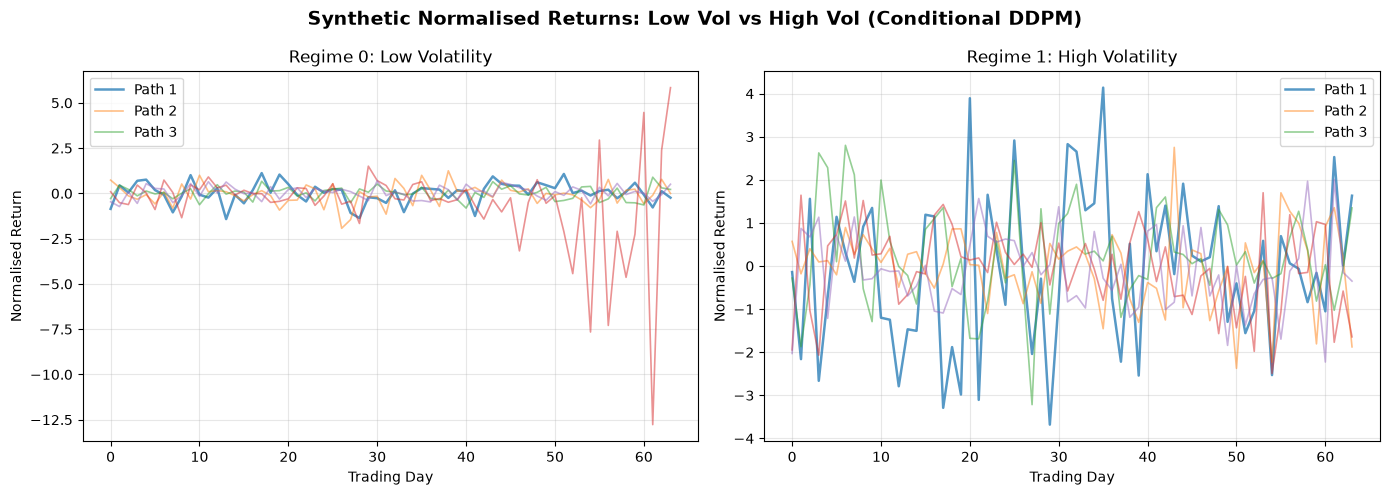

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Synthetic Normalised Returns: Low Vol vs High Vol (Conditional DDPM)', fontsize=14, fontweight='bold')

# Plot 5 random samples from each regime
np.random.seed(42)
idx = np.random.choice(len(low_np), 5, replace=False)

for i, k in enumerate(idx):
    alpha_val = 0.75 if i == 0 else 0.5
    lw        = 1.8  if i == 0 else 1.2
    axes[0].plot(low_np[k],  alpha=alpha_val, linewidth=lw, label=f'Path {i+1}' if i < 3 else '')
    axes[1].plot(high_np[k], alpha=alpha_val, linewidth=lw, label=f'Path {i+1}' if i < 3 else '')

axes[0].set_title('Regime 0: Low Volatility', fontsize=12)
axes[0].set_xlabel('Trading Day')
axes[0].set_ylabel('Normalised Return')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Regime 1: High Volatility', fontsize=12)
axes[1].set_xlabel('Trading Day')
axes[1].set_ylabel('Normalised Return')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'nb04_cond_visual.png'), dpi=150, bbox_inches='tight')
plt.savefig(os.path.join(FIG_DIR, 'nb04_cond_visual.pdf'), bbox_inches='tight')
plt.show()

## Notebook 04 Complete

### What was achieved:
1. **Trained** a Conditional DDPM with Classifier-Free Guidance on NIFTY50 volatility regimes
2. **Verified** conditioning with the "same noise, different regime" test (Cell 12)
3. **Verified** variance ordering: High-Vol samples have larger variance than Low-Vol (Cell 13)
4. **Generated** 500 synthetic paths per regime, saved to `outputs/samples/`
5. **Saved** publication-quality figures (PNG + PDF) to `outputs/figures/`

### Checkpoint Artifacts:
| File | Description |
|---|---|
| `outputs/checkpoints/cond_ddpm_ema_best.pth` | Best EMA model (lowest val loss) |
| `outputs/checkpoints/cond_ddpm_ema_periodic.pth` | Latest periodic checkpoint (every 10 epochs) |
| `outputs/checkpoints/cond_training_history.json` | Full loss history |
| `outputs/samples/cond_samples_low.pt` | 500 Low-Vol synthetic sequences |
| `outputs/samples/cond_samples_high.pt` | 500 High-Vol synthetic sequences |

### Next Step
→ **Notebook 05** (`05_evaluation.ipynb`) — Denormalize the data and rigorously compare Unconditional vs Conditional DDPM against real NIFTY50 Stylized Facts.